In [1]:
# import modules
import numpy as np
import random
import math
import pandas as pd

import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time

import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

np.set_printoptions(suppress=True)


## Create the random spatial field 

In [2]:
# First generate some synthetic data
# Generate random covariate fields
# We use 2 simulated covariates

L = 50.0 # size of domain
x = y = np.arange(0,L+1,1)
var=1.0


2022-08-17 10:39:58.396075: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-08-17 10:40:06.572607: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15391 MB memory:  -> device: 0, name: Quadro GP100, pci bus id: 0000:3b:00.0, compute capability: 6.0
2022-08-17 10:40:17.456096: I tensorflow/core/util/cuda_solvers.cc:180] Creating CudaSolver handles for stream 0x5653a64b48e0


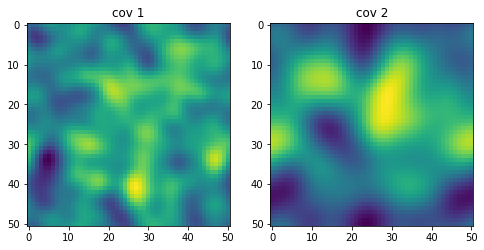

In [3]:
# Make the environment using a correlated periodic Gaussian random field

x = y = np.arange(0,L+1,1)
xx, yy = np.meshgrid(x,y)

positions = np.vstack([xx.ravel(), yy.ravel()]).T

len_scale_1 = 5
period = np.float64(L)
periodic_len = (2**0.5)*len_scale_1*np.pi/period


kernel = tfp.math.psd_kernels.ExpSinSquared(length_scale=periodic_len,period=period)
gp = tfd.GaussianProcess(kernel, positions)

samples = gp.sample()
cov1 = samples.numpy().reshape(51,51)


len_scale_2 = 10
period = np.float64(L)
periodic_len = (2**0.5)*len_scale_2*np.pi/period


kernel = tfp.math.psd_kernels.ExpSinSquared(length_scale=periodic_len,period=period)
gp = tfd.GaussianProcess(kernel, positions)

samples = gp.sample()
cov2 = samples.numpy().reshape(51,51)


fig, ax = plt.subplots(1,2,figsize=(8,6))
ax[0].set_title('cov 1')
ax[0].imshow(cov1)
ax[1].set_title('cov 2')
ax[1].imshow(cov2)
plt.show()

cov_cube = np.stack((cov1,cov2))


## Simulate the individuals

In [4]:
# Simulating observation from centred model
 
nbObs=10001 #nbObs Number of observations
beta=np.array([[-1.5,1.8]]) # Vector of resource selection coefficients
allr=np.ones(nbObs) # Vector of radii for movement kernel, or standard deviations
cov=cov_cube #Array of covariates (one layer for each covariate)
xy0=[25,25] #Initial location
npts=100 # Number of potential endpoints to sample at each time step
xy1=np.zeros((nbObs,2))
xy1[0] = xy0
x_min = [0., 0.]
x_max = [L, L]
   
# Convert the covariates to tensor 
cov_tensor = tf.transpose(tf.convert_to_tensor(cov_cube,dtype=tf.float32),[2,1,0])
beta_tensor = tf.convert_to_tensor(beta,dtype=tf.float32)
    
C=np.zeros((2))
allrsf=np.zeros(npts)
dt = np.zeros(nbObs)
ID = np.zeros(nbObs)
cid=0
t = 1
for t in tqdm(range(1,nbObs)):
    cdt = np.random.normal(loc=1.0,scale=0.1)
    C[0] = np.random.normal(loc=xy1[t-1,0],scale=allr[t-1]*((0.5*cdt)**0.5))
    C[1] = np.random.normal(loc=xy1[t-1,1],scale=allr[t-1]*((0.5*cdt)**0.5))
        
    grid=np.zeros((npts,2))
    # sample npts points in the circle
    
    grid[:,0]=np.random.normal(loc=C[0], scale=allr[t-1]*((0.5*cdt)**0.5),size=npts)
    grid[:,1]=np.random.normal(loc=C[1], scale=allr[t-1]*((0.5*cdt)**0.5),size=npts)               
    
    # Convert grid to tensor before extracting the values
    zgrid=tf.convert_to_tensor(grid%L,dtype=tf.float32)

    # calculate the covariates at the step end locations using tensorflow probability
    cov_xy_end = tfp.math.batch_interp_regular_nd_grid(zgrid, x_min, x_max, cov_tensor, axis=-3)
            
    # calculate the rsf
    allrsf= np.array(tf.exp(tf.reduce_sum(tf.multiply(cov_xy_end,beta_tensor),axis=-1)))
        
    next_point=random.choices(population=grid,weights=allrsf,k=1)
    
    dt[t-1]=cdt
    xy1[t]=next_point[0] 
        
    ID[t]=cid



100%|██████████| 10000/10000 [01:36<00:00, 103.76it/s]


In [9]:
# Saving the data to csv
hj=pd.DataFrame(xy1)
hj.columns=["x","y"]
date=pd.DataFrame(dt)
date.columns=["time"]
Animal_ID=pd.DataFrame(ID)
Animal_ID.columns=["ID"]

# Creating a list of data and merging them by columns
simdata=[hj,date,Animal_ID]
simdata=pd.concat(simdata,axis=1)

pos_filename  = "pos_N_" + str(nbObs-1) + "_b0_" + str(beta[0][0]) + "_b1_" + str(beta[0][1])+ ".csv"
grid_filename  = "cov_N_" + str(nbObs-1) + "_b0_" + str(beta[0][0]) + "_b1_" + str(beta[0][1])+ ".npy"
#Saving the data
simdata.to_csv(pos_filename,index=None)
np.save(grid_filename,cov_cube)


In [10]:
ls

cov_N_10000_b0_-1.5_b1_1.8.npy  pos_N_10000_b0_-1.5_b1_1.8.csv
data_generation.ipynb
